In [66]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/deeppythonist/brain-tumor-mri-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: yugsh8080
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/deeppythonist/brain-tumor-mri-dataset


100%|██████████| 151M/151M [00:10<00:00, 14.7MB/s]


In [3]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.models import Sequential


In [5]:
test=keras.utils.image_dataset_from_directory(
    directory='/content/brain-tumor-mri-dataset/test',
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256)
)

train=keras.utils.image_dataset_from_directory(
    directory='/content/brain-tumor-mri-dataset/train',
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256)
)

Found 1430 files belonging to 4 classes.
Found 5723 files belonging to 4 classes.


In [6]:
# Normalize
def process(image,label):
    image=tf.cast(image/255. ,tf.float32)
    return image,label

train=train.map(process)
test=test.map(process)

In [11]:
model = Sequential()

model.add(Conv2D(16,(3,3),activation='relu',
                 padding='same',
                 input_shape=(256,256,3)))
model.add(MaxPooling2D())

model.add(Conv2D(32,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D())



model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D())


model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D())

model.add(Conv2D(256,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D())

model.add(Conv2D(512,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256,activation='relu'))
model.add(Dense(4,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,671,204 (14.00 MB)

 Trainable params: 3,671,204 (14.00 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [14]:
model.fit(train,epochs=10,validation_data=test)

Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy: 0.6507 - loss: 0.7916 - val_accuracy: 0.8287 - val_loss: 0.4563
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.8387 - loss: 0.4149 - val_accuracy: 0.8944 - val_loss: 0.3022
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.8904 - loss: 0.2897 - val_accuracy: 0.8790 - val_loss: 0.3368
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 21s 63ms/step - accuracy: 0.9270 - loss: 0.1927 - val_accuracy: 0.9140 - val_loss: 0.2079
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9478 - loss: 0.1387 - val_accuracy: 0.9224 - val_loss: 0.2066
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - accuracy: 0.9612 - loss: 0.1032 - val_accuracy: 0.9538 - val_loss: 0.1628
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - accuracy: 0.9759 - loss: 0.0653 - val_accuracy: 0.9392 - val_loss: 0.1789
Epoch 8/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 21s 63ms/step - accuracy: 0.9867 - loss: 0.0382 - 

In [16]:
import numpy as np

predictions = model.predict(test)
predicted_classes = np.argmax(predictions, axis=1)

print(predicted_classes)

45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step
[2 1 2 ... 3 2 0]


In [48]:
import cv2
test_img=cv2.imread('/content/no-0002.jpg')

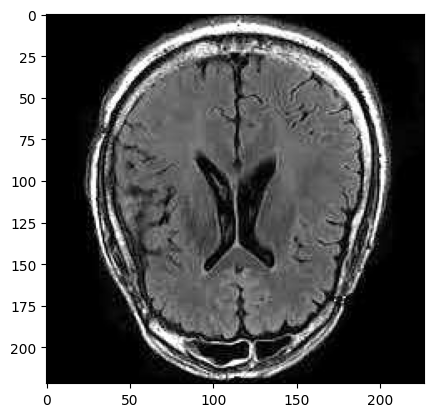

In [49]:
import matplotlib.pyplot as plt
plt.imshow(test_img)

In [50]:
test_img=cv2.resize(test_img,(256,256))

In [51]:
test_input=test_img.reshape((1,256,256,3))

In [52]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


array([[0., 0., 1., 0.]], dtype=float32)

In [54]:
pred = model.predict(test_input)
print(pred)
print(np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
[[0. 0. 1. 0.]]
2


In [63]:
import os

classes = sorted(os.listdir('/content/brain-tumor-mri-dataset/train'))
print(classes)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [55]:
import numpy as np

for images, labels in test.take(1):
    preds = model.predict(images)

    print("Predictions:")
    print(np.argmax(preds, axis=1)[:20])

    print("True labels:")
    print(labels.numpy()[:20])

    break

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 981ms/step
Predictions:
[2 3 3 3 2 2 0 0 3 2 2 0 1 0 1 2 0 2 3 1]
True labels:
[2 3 3 3 2 2 0 0 3 2 2 0 1 0 3 2 0 2 3 0]


In [60]:
import cv2
import numpy as np

img = cv2.imread('/content/gl-0013.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (256, 256))

img = img.astype('float32') / 255.0

img = np.expand_dims(img, axis=0)

pred = model.predict(img)

print("Probabilities:", pred[0])
print("Predicted class:", np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Probabilities: [9.9999988e-01 1.5130774e-07 7.7129601e-11 6.6494503e-09]
Predicted class: 0


In [65]:
import cv2
import numpy as np

# Load image
img = cv2.imread('/content/gl-0060.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (256, 256))

# Normalize
img = img.astype('float32') / 255.0

# Add batch dimension
img = np.expand_dims(img, axis=0)

# Predict
pred = model.predict(img)

# Get predicted class index
pred_idx = np.argmax(pred)

# Get class name
class_names = sorted(os.listdir('/content/brain-tumor-mri-dataset/train'))

print("Predicted Index:", pred_idx)
print("Predicted Class:", class_names[pred_idx])
print("Confidence:", pred[0][pred_idx] * 100, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Index: 0
Predicted Class: glioma
Confidence: 99.99998 %
